<a href="https://colab.research.google.com/github/ClassNeuralNetwork/classification-chess/blob/main/chess_prediction_advantage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalação de biblioteca necessária para manipulações de tabuleiro de xadrez

!pip install chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 61.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147775 sha256=b27ae7e547168f6dfa72edf92e657a3c0abb84c46a96412f36088b85b28f2b2b
  Stored in directory: /root/.cache/pip/wheels/83/1f/4e/8f4300f7dd554eb8de70ddfed96e94d3d030ace10c5b53d447
Successfully built chess


In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import os
import chess
import kagglehub

In [3]:
# Recuperando dados do dataset
path = kagglehub.dataset_download("ronakbadhe/chess-evaluations")
csv_path=os.path.join(path, 'chessData.csv')

# pegando apenas 250000 dados do dataset, visto que ele tem 16 milhões de linhas
df = pd.read_csv(csv_path).sample(n=250000, random_state=42)
df.head()

100%|██████████| 200M/200M [00:02<00:00, 90.6MB/s]

Extracting files...


,FEN,Evaluation
11784899,r3k2r/1b2bppp/p1n1pn2/1p2N1B1/8/2NB1P2/PPP3PP/...,-35
8860705,r3k2r/1pp2p2/1bnp1q2/p2Bp1p1/PP2P1bP/1QPP1N2/3...,-201
7376649,6k1/2p3pp/8/8/P3R3/3r1PP1/5K1P/8 b - - 0 30,+121
2224083,1r6/2rnppkp/1q1p2n1/2pP2p1/2b5/1P4PP/P1QNPPB1/...,+280
4108821,5k2/3R4/1p1p4/3n2pp/8/8/PP6/6K1 b - - 1 35,+328


In [4]:
'''
Converte valores de evaluation para binário
  1.0 = vantagem das brancas
  0.0 = vantagem das pretas
  None = posição equilibrada
'''

def clean_evaluation(evaluation):
  value = str(evaluation).replace('+', '')


  # Verifica se o tabuleiro está em xeque mate
  if 'm' in value or '#' in value:
    if '-' in value:
      return 0.0

    else:
      return 1.0

  numeric_note = float(value)

  # Verifica se o tabuleiro está equilibrado
  if abs(numeric_note) < 50:
    return None

  # Verifica posições de vantagem das pretas ou brancas
  if numeric_note > 0:
    return 1.0
  else:
    return 0.0


In [5]:
# Cria a coluna target com os dados evaluations limpos
df['Target'] = df['Evaluation'].apply(clean_evaluation)

# Transformando dados da coluna target em inteiro e retirando dados nulos
df = df.dropna(subset=['Target'])
df['Target'] = df['Target'].astype(int)

df_class_1 = df[df['Target'] == 1]
df_class_0 = df[df['Target'] == 0]

df_class_1 = df_class_1.sample(n=len(df_class_0), random_state=42)
df= pd.concat([df_class_0, df_class_1]).sample(frac=1, random_state=42).reset_index(drop=True)


# organizando entradas e saídas do treinamento
entrada = df['FEN'].values

saida_desejada = df['Target'].values

entrada_treino, entrada_teste, saida_desejada_treino, saida_desejada_teste = train_test_split(entrada, saida_desejada, test_size=0.2, random_state=42)

In [7]:
print('Balanceamento dos dados')
print(df['Target'].value_counts(normalize=True))

Balanceamento dos dados
Target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [8]:
'''
Recebe código FEN, que representa um estado do tabuleiro de xadrez e converte em um vetor númerico que o modelo consegue processar
'''
def FEN_to_number_array(fen_code):

  # Gera um tabuleiro com base no fen informado
  board = chess.Board(fen_code)

  # Valor das peças
  PIECES_VALUES = {
      chess.PAWN: 1,
      chess.KNIGHT: 3,
      chess.BISHOP: 3,
      chess.ROOK: 5,
      chess.QUEEN: 9,
      chess.KING: 10,
  }

  board_values = []


  # Percorre as 64 casas do tabuleiro verificando o que está em cada uma delas e armazenando o valor correspondente
  for i in range(64):
    piece = board.piece_at(i)

    # Espaço vazio
    if piece == None:
      board_values.append(0)

    # Verifica se o que está no espaço é uma peça branca ou preta
    else:
      base_value = PIECES_VALUES[piece.piece_type]

      if piece.color == chess.WHITE:
        board_values.append(base_value)
      else:
        board_values.append(base_value * (-1))


  # Valores para ajudar a análise da rede quanto ao tabuleiro
  vez = 1.0 if board.turn == chess.WHITE else -1.0
  xeque = 1.0 if board.is_check() else 0.0
  saldo_material = sum(board_values) / 100.0
  roque_branco_disponivel = 1.0 if board.has_castling_rights(chess.WHITE) else 0.0
  roque_preto_disponivel = 1.0 if board.has_castling_rights(chess.BLACK) else 0.0
  mobilidade = len(list(board.legal_moves)) / 50.0

  return np.array(
    board_values +
   [vez, xeque, saldo_material, roque_branco_disponivel, roque_preto_disponivel, mobilidade]
  )

In [9]:
# Manipulando dados de entrada para formato númerico

entrada_treino_pura = np.array([FEN_to_number_array(fen) for fen in entrada_treino])
entrada_teste_pura = np.array([FEN_to_number_array(fen) for fen in entrada_teste])

In [10]:
# Padronizando dados de entrada

scaler = StandardScaler()

entrada_treino_padronizada = scaler.fit_transform(entrada_treino_pura)
entrada_teste_padronizada = scaler.transform(entrada_teste_pura)

In [11]:
# Criação do modelo
model = tf.keras.models.Sequential()

model.add(Dense(units=150, activation='relu', input_shape=(70,)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=80, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=50, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(units=1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 150)            │        10,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150)            │           600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │        12,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80)             │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         4,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,951 (109.18 KB)

 Trainable params: 27,391 (107.00 KB)

 Non-trainable params: 560 (2.19 KB)

In [12]:
# Mecanismo de parada forçada monitorando a acuracia do modelo
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    min_delta=0.001
)

In [13]:
# compilando o modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics = ['accuracy'])

In [14]:
# Executando o treinamento

historico = model.fit(
    entrada_treino_padronizada,
    saida_desejada_treino,
    epochs=100,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stopping],
)

Epoch 1/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6757 - loss: 0.6155 - val_accuracy: 0.7558 - val_loss: 0.5132
Epoch 2/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7535 - loss: 0.5144 - val_accuracy: 0.7743 - val_loss: 0.4734
Epoch 3/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7706 - loss: 0.4843 - val_accuracy: 0.7800 - val_loss: 0.4619
Epoch 4/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7783 - loss: 0.4711 - val_accuracy: 0.7797 - val_loss: 0.4578
Epoch 5/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7819 - loss: 0.4633 - val_accuracy: 0.7846 - val_loss: 0.4528
Epoch 6/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7843 - loss: 0.4581 - val_accuracy: 0.7866 - val_loss: 0.4498
Epoch 7/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7866 - loss: 0.4538 - val_accuracy: 0.7871 - val_loss: 0.4486
Epoch 8/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7890 - loss: 0.4498 - val_a

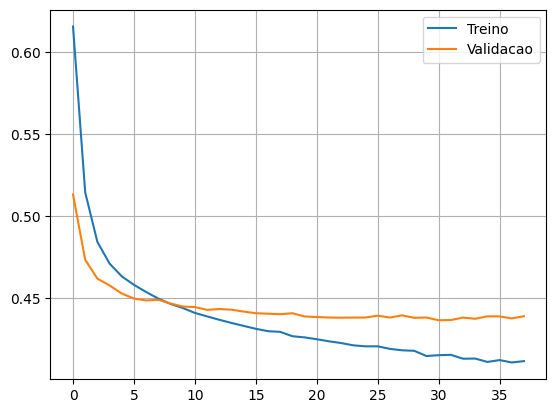

In [15]:
# Função perca

plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='Validacao')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
previsoes_probabilisticas = model.predict(entrada_teste_padronizada)

saida_predita = (previsoes_probabilisticas > 0.5).astype(int)

saida_desejada_real = saida_desejada_teste

888/888 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [17]:
# Precisão

precision = precision_score(saida_desejada_teste, saida_predita)
print(f'Precisão do modelo: {(precision*100):.2f}%')

Precisão do modelo: 78.75%


In [18]:
# Recall

recall = recall_score(saida_desejada_teste, saida_predita)
print(f'Recall do modelo: {(recall*100):.2f}%')

Recall do modelo: 81.51%


In [19]:
# F1 Score

f1 = f1_score(saida_desejada_teste, saida_predita)
print(f'F1 score do modelo: {(f1*100):.2f}%')

F1 score do modelo: 80.11%


In [20]:
# Acuracia

accuracy = accuracy_score(saida_predita, saida_desejada_real)
print(f'Acuracia do modelo: {(accuracy*100):.2f}%')

Acuracia do modelo: 79.73%


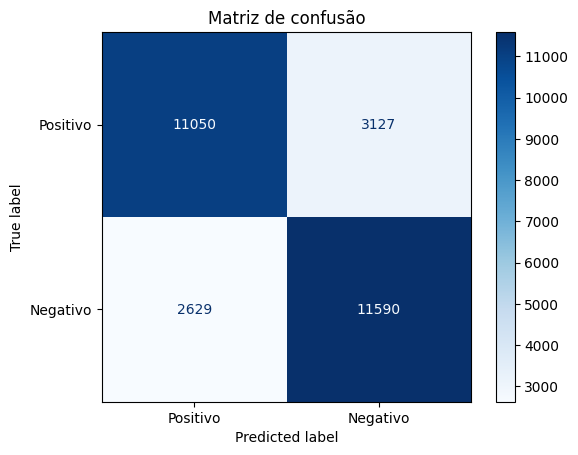

In [21]:
# Matriz de confusão

cm = confusion_matrix(saida_desejada_real, saida_predita)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positivo', 'Negativo'])
cmd.plot(cmap='Blues')
plt.title('Matriz de confusão')
plt.show()


In [22]:
def predict_position(fen):
  position_values = FEN_to_number_array(fen)

  padronized_position_values = scaler.transform([position_values])

  predict = model.predict(padronized_position_values)[0][0]

  print(f'Probabilidade de vitória das brancas: {(predict * 100):.2f}%')

  if predict > 0.5:
    print('Vantagem das brancas')
  else:
    print('Vantagem das pretas')

In [23]:
predict_position('rnbqkbnr/ppp1pppp/8/8/2pP4/8/PPP1PPPP/RNBQKBNR w KQkq - 0 3')

predict_position('rnb1kbnr/pp1ppppp/8/q1p5/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 3')

predict_position('r1bqkb1r/pppp1ppp/2n2n2/4p3/4P3/2N2N2/PPPP1PPP/R1BQKB1R w KQkq - 4 4')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Probabilidade de vitória das brancas: 84.71%
Vantagem das brancas
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Probabilidade de vitória das brancas: 74.33%
Vantagem das brancas
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Probabilidade de vitória das brancas: 96.54%
Vantagem das brancas


In [25]:
# Salvando o modelo
model.save('chess_prediction_advantage.keras')